In [1]:
import os, sys, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

import time
from datetime import datetime

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, auc, accuracy_score, average_precision_score

import joblib

In [2]:
# Define the Neural Network Model
class NeuralNetwork(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, hidden_size3, output_size=1):
        super(NeuralNetwork, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.bn1 = nn.BatchNorm1d(hidden_size1)  # Batch normalization
        self.dropout1 = nn.Dropout(0.3)  # Dropout to avoid overfitting

        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.bn2 = nn.BatchNorm1d(hidden_size2)
        self.dropout2 = nn.Dropout(0.3)

        self.fc3 = nn.Linear(hidden_size2, hidden_size3)
        self.bn3 = nn.BatchNorm1d(hidden_size3)
        self.dropout3 = nn.Dropout(0.3)

        self.fc4 = nn.Linear(hidden_size3, output_size)

    def forward(self, x):
        x = self.dropout1(torch.relu(self.bn1(self.fc1(x))))
        x = self.dropout2(torch.relu(self.bn2(self.fc2(x))))
        x = self.dropout3(torch.relu(self.bn3(self.fc3(x))))
        x = self.fc4(x).squeeze(-1)
        return x


class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, inputs, targets):
        bce_loss = self.bce(inputs, targets)
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [3]:
def evaluate_metrics(model, data_loader, device):
    model.eval()
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            labels = labels.to(device).float()

            logits = model(inputs).squeeze(-1)
            probs = torch.sigmoid(logits)

            all_labels.append(labels.cpu())
            all_probs.append(probs.cpu())

    all_labels = torch.cat(all_labels).numpy()
    all_probs = torch.cat(all_probs).numpy()

    aupr = average_precision_score(all_labels, all_probs)
    try:
        auroc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auroc = float('nan')  # If only one class present

    return aupr, auroc


def create_directory(dir_path):
    """
    Creates a directory if it does not exist.

    Parameters:
    dir_path (str): Path to the directory to be created.
    """
    os.makedirs(dir_path, exist_ok=True)  # Creates the directory and ignores if it exists
    print(f"Directory '{dir_path}' is ready.")


In [4]:
def concat_df_in_dir(input_direc, iter_num=20, tail='.tsv', sep_='\t'):
    # Build file name tail list to ensure the correct order
    file_tail_list = []
    for i in range(iter_num):
        file_tail = '_' + str(i) + tail
        file_tail_list.append(file_tail)

    df_list = []
    files = os.listdir(input_direc)
    for f in range(iter_num):
        file_tail = file_tail_list[f]
        for file in files:
            if file.endswith(file_tail):
                print(file)
                df = pd.read_csv(input_direc+file, sep=sep_, index_col=None)
                df_list.append(df)
    df_all = pd.concat(df_list)
    return df_all


def create_GIV_input_df(input_dir="/home/myersc/zhan6668/DepGI/data/input/",
                    giv_dir='GIV/', iter_num=10):
    df_SL = concat_df_in_dir(input_dir+giv_dir, iter_num=iter_num, tail='.tsv')
    print(df_SL.shape)
    df_SL = df_SL.reset_index().drop('index', axis=1)
    return df_SL


def recall_at_k(y_true, y_pred, K):
    '''
    Compute Recall@K.
    Parameters:
    - y_true: array-like of shape (n_samples,), binary labels (1 for relevant, 0 for irrelevant)
    - y_pred: array-like of shape (n_samples,), predicted probabilities
    - K: int, number of top elements to consider
    Returns:
    - recall_at_K: float
    '''
    # Sort by predicted probability in descending order
    top_k_indices = np.argsort(y_pred)[::-1][:K]
    # Count the number of relevant items in the top K
    relevant_at_k = np.sum(np.array(y_true)[top_k_indices])
    # Total number of relevant items in the entire dataset
    total_relevant = np.sum(y_true)
    # Recall@K formula
    return relevant_at_k / total_relevant if total_relevant > 0 else 0.0

def precision_at_k(y_true, y_pred, K):
    '''
    Compute Precision@K.
    Parameters:
    - y_true: array-like of shape (n_samples,), binary labels (1 for relevant, 0 for irrelevant)
    - y_pred: array-like of shape (n_samples,), predicted probabilities
    - K: int, number of top elements to consider
    Returns:
    - precision_at_K: float
    '''
    # Sort by predicted probability in descending order
    top_k_indices = np.argsort(y_pred)[::-1][:K]
    # Count the number of relevant items in the top K
    relevant_at_k = np.sum(np.array(y_true)[top_k_indices])
    # Precision@K formula
    return relevant_at_k / K if K > 0 else 0.0


def plot_ROC_PR(all_labels, all_probs, plt_direc='./ROC_PR_curves.pdf', K=10):
    # Generate ROC and PR curves
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    precision, recall, _ = precision_recall_curve(all_labels, all_probs)
    average_precision = average_precision_score(all_labels, all_probs)

    # Calculate AUC for ROC and PR
    roc_auc = auc(fpr, tpr)
    pr_auc = auc(recall, precision)
    print(f'ROC AUC: {roc_auc:.4f}')
    print(f'PRC AUC: {pr_auc:.4f}')
    print(f"Average Precision: {average_precision:.4f}")

    # Calculate Precision@K and Recall@K
    recall_k = recall_at_k(all_labels, all_probs, K)
    precision_k = precision_at_k(all_labels, all_probs, K)
    print(f"Recall@{K}: {recall_k:.4f}")
    print(f"Precision@{K}: {precision_k:.4f}")

    # Plot ROC curve
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()

    # Plot Precision-Recall curve
    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, color='green', label=f'PR curve (AUC = {pr_auc:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()

    plt.tight_layout()
    if plt_direc is not None:
        plt.savefig(plt_direc, dpi=300)
    #plt.show()
    plt.close()
    return [roc_auc, pr_auc, average_precision, recall_k, precision_k]


In [5]:
# Function to log messages with timestamp
def log_message(message):
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    print(f"[{timestamp}] {message}")

In [6]:
def plot_losses(train_losses, val_losses, train_label="Training Loss", val_label="Validation Loss", plt_direc=None):
    epochs = list(range(1, len(train_losses) + 1))
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_losses, label=train_label, marker="o")
    plt.plot(epochs, val_losses, label=val_label, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss Over Epochs")
    plt.legend()
    plt.grid(True)
    if plt_direc is not None:
        plt.savefig(plt_direc, dpi=300)
    #plt.show()


In [7]:
def filter_unique_pairs_by_lowest_FDR(df, col1='Gene', col2='Query', col_fdr='FDR'):
    # Drop rows with missing values in the relevant columns
    df = df.dropna(subset=[col1, col2, col_fdr])
    # Remove self-interactions
    idx_self = df[df[col1]==df[col2]].index
    df = df.drop(idx_self, axis=0)
    # Normalize the pairs directly into a tuple without creating a new column
    normalized_pairs = df[[col1, col2]].apply(lambda row: tuple(sorted(row)), axis=1)
    # Combine normalized pairs and column 'C' into a new DataFrame
    normalized_df = pd.DataFrame({'normalized_pair': normalized_pairs, col_fdr: df[col_fdr]})
    # Group by the normalized pair and get the index of the row with the lowest 'C' for each pair
    min_c_indices = normalized_df.groupby('normalized_pair')[col_fdr].idxmin()
    # Use these indices to filter the original DataFrame
    filtered_df = df.loc[min_c_indices]
    return filtered_df.reset_index(drop=True)

In [8]:
def NN_held_out_test(model_direc, df_SL, non_feature_cols = ['Gene', 'Query', 'qGI_score', 'FDR', 'GI_standard', 'GI_stringent',
       'GI_standard_Type1', 'GI_standard_Type2', 'GI_standard_Type3',
       'GI_stringent_Type1', 'GI_stringent_Type2', 'GI_stringent_Type3'],
                     label_col='GI_stringent_Type2', plt_direc='test.pdf', 
                     output_table_direc='.tsv', scaler_direc='scaler.joblib',
                    topk=100):
    device = (
        "cuda"
        if torch.cuda.is_available()
        else "mps"
        if torch.backends.mps.is_available()
        else "cpu"
    )
    print(f"Using {device} device")

    model = torch.load(model_direc, map_location=torch.device(device))
    #model.to(device)
    model.eval()  # Set the model to evaluation mode

    print(model_direc)
    print("Entire model loaded successfully.")

    features = df_SL.drop(columns=non_feature_cols)#.values
    labels = df_SL[label_col]#.values
    print(label_col)

    # Remove NAs
    features.dropna(axis=0, how='any', inplace=True)
    labels = labels.loc[features.index]
    print(features.shape)
    
    df_test = df_SL.loc[features.index]
    df_test = df_test[non_feature_cols]

    # Standardize the features using trained stats
    #scaler = StandardScaler()
    #features = scaler.fit_transform(features)
    scaler = joblib.load(scaler_direc)
    features = scaler.transform(features)

    # Convert the data into PyTorch tensors
    X_new = torch.tensor(features, dtype=torch.float32).to(device)  # Ensure correct dtype

    # Make predictions
    with torch.no_grad():
        outputs = model(X_new).squeeze(-1)
        probabilities = torch.sigmoid(outputs).cpu().numpy()
        predictions = (probabilities >= 0.5)#.long() # Get predicted class
        #predictions = torch.argmax(outputs, dim=1).cpu().numpy()  # Get predicted class
        #probabilities = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()

    print(f'Accuracy on test set: {100 * accuracy_score(labels, predictions):.2f}%')
    #plot_ROC_PR(labels, probabilities, plt_direc=plt_direc)
    perf_metrics = plot_ROC_PR(labels, probabilities, 
                               plt_direc=plt_direc, K=topk)

    df_test['prediction'] = predictions
    df_test['predict_proba'] = probabilities
    df_test.to_csv(output_table_direc, sep='\t')
    return df_test, perf_metrics

In [9]:
non_feature_cols = ['Gene', 'Query', 'qGI_score', 'FDR', 'GI_standard', 'GI_stringent',
                   'GI_standard_Type1', 'GI_standard_Type2', 'GI_standard_Type3',
                   'GI_stringent_Type1', 'GI_stringent_Type2', 'GI_stringent_Type3']

In [10]:
input_direc = "/home/myersc/zhan6668/DepGI/data/input/GIV_24Q4/"

df_SL_heldout = create_GIV_input_df(input_dir=input_direc,
                giv_dir='GIV_24Q4_heldout/', iter_num=11)

qGI_heldout_24Q4_GIV_0.tsv
qGI_heldout_24Q4_GIV_1.tsv
qGI_heldout_24Q4_GIV_2.tsv
qGI_heldout_24Q4_GIV_3.tsv
qGI_heldout_24Q4_GIV_4.tsv
qGI_heldout_24Q4_GIV_5.tsv
qGI_heldout_24Q4_GIV_6.tsv
qGI_heldout_24Q4_GIV_7.tsv
qGI_heldout_24Q4_GIV_8.tsv
qGI_heldout_24Q4_GIV_9.tsv
qGI_heldout_24Q4_GIV_10.tsv
(2189892, 268)


In [11]:
df_SL_heldout

,Gene,Query,qGI_score,FDR,GI_standard,GI_stringent,GI_standard_Type1,GI_standard_Type2,GI_standard_Type3,GI_stringent_Type1,...,exp_118,exp_119,exp_120,exp_121,exp_122,exp_123,exp_124,exp_125,exp_126,exp_127
0,A1BG,ABCB1,-0.194490,0.416109,NaN,NaN,0,0,0,0,...,-0.162814,6.624247,4.939270,0.223327,-1.352390,-1.832275,10.815903,-2.209463,-0.923812,0.514347
1,A1BG,ABHD18,0.041025,0.990875,NaN,NaN,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,A1BG,ALKBH1,0.176911,0.700077,NaN,NaN,0,0,0,0,...,2.100424,6.328823,5.009311,0.423715,-0.948143,-2.823758,2.444582,1.069029,-1.612594,1.060910
3,A1BG,APOBEC3A,-0.075643,0.835830,NaN,NaN,0,0,0,0,...,2.167239,6.821758,4.923169,-0.092498,-0.889341,-1.651713,4.664135,2.389411,1.273582,-1.629603
4,A1BG,APOBEC3B,0.023686,0.996608,NaN,NaN,0,0,0,0,...,3.167728,8.801681,7.957367,3.585494,-0.383170,-1.799275,5.444688,-0.563660,-0.416245,-0.092525
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2189887,ZZZ3,VPS33A,-0.060622,0.900589,NaN,NaN,0,0,0,0,...,-0.674722,5.816184,1.666922,0.777897,0.358467,-1.469143,2.545601,0.090125,-1.440368,-0.359987
2189888,ZZZ3,WNK2,-0.051066,0.984051,NaN,NaN,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2189889,ZZZ3,WNK3,-0.204007,0.571260,NaN,NaN,0,0,0,0,...,-0.033937,7.591174,1.592040,0.472127,0.756832,-1.054088,3.723761,0.447634,0.098621,-2.408466
2189890,ZZZ3,WTAP,0.041413,0.928375,NaN,NaN,0,0,0,0,...,0.506781,8.073312,1.269261,-1.288032,0.915663,-2.597041,1.101285,0.409666,-2.192609,0.979609


In [12]:
df_SL_heldout = filter_unique_pairs_by_lowest_FDR(df_SL_heldout, col1='Gene', col2='Query', col_fdr='FDR')

In [24]:
df_MTOR_heldout = df_SL_heldout[df_SL_heldout['Query']=='MTOR']

In [25]:
df_MTOR_heldout

,Gene,Query,qGI_score,FDR,GI_standard,GI_stringent,GI_standard_Type1,GI_standard_Type2,GI_standard_Type3,GI_stringent_Type1,...,exp_118,exp_119,exp_120,exp_121,exp_122,exp_123,exp_124,exp_125,exp_126,exp_127
64,A1BG,MTOR,-0.094861,0.850521,NaN,NaN,0,0,0,0,...,2.839726,7.318722,5.415388,1.040632,-0.836750,-3.090039,3.324207,0.659756,-2.195414,0.926160
187,A1CF,MTOR,-0.083701,0.984771,NaN,NaN,0,0,0,0,...,-0.379699,7.386625,-0.053300,-0.852229,1.414813,0.847497,6.421395,-0.252559,1.982687,-3.126780
310,A2M,MTOR,0.296972,0.503213,NaN,NaN,0,0,0,0,...,0.434081,9.195257,4.603049,5.498988,1.713005,0.071381,10.177487,2.271648,0.587046,0.289807
433,A2ML1,MTOR,0.104500,0.785691,NaN,NaN,0,0,0,0,...,0.560010,8.229543,0.403629,-0.543205,1.576413,0.883667,4.582395,1.418001,2.658110,-5.606432
556,A3GALT2,MTOR,0.095012,0.908000,NaN,NaN,0,0,0,0,...,0.502244,7.581849,1.568455,-0.383912,0.615599,-0.210475,4.515048,0.892455,1.520068,-2.801556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1704910,ZYG11A,MTOR,0.088709,0.932267,NaN,NaN,0,0,0,0,...,0.495763,9.756164,1.905713,1.226961,1.342182,-1.422839,3.707060,0.495604,-0.955045,-4.888194
1704911,ZYG11B,MTOR,-0.027329,0.990031,NaN,NaN,0,0,0,0,...,0.884922,5.097012,1.770713,0.798235,1.634539,-1.247151,2.285097,-0.056903,-0.618831,-0.341584
1704912,ZYX,MTOR,0.146266,0.842548,NaN,NaN,0,0,0,0,...,-0.750651,9.757477,3.071074,1.836534,2.716395,-1.791071,3.869044,1.083620,-0.369520,1.291225
1704913,ZZEF1,MTOR,0.169984,0.893095,NaN,NaN,0,0,0,0,...,0.546919,5.342927,1.327468,0.645304,1.404797,0.057048,3.341160,-0.583253,-1.838322,-0.227431


In [27]:
df_MTOR_heldout[df_MTOR_heldout['GI_stringent_Type2']==1]

,Gene,Query,qGI_score,FDR,GI_standard,GI_stringent,GI_standard_Type1,GI_standard_Type2,GI_standard_Type3,GI_stringent_Type1,...,exp_118,exp_119,exp_120,exp_121,exp_122,exp_123,exp_124,exp_125,exp_126,exp_127
1322582,GLIS1,MTOR,-0.705382,9.837123e-04,negative,negative,1,1,0,1,...,0.865126,7.964436,2.624600,0.422216,0.336064,-0.481833,4.434941,0.377138,1.144090,-0.766160
1326726,GNA13,MTOR,-0.618909,3.688156e-03,negative,negative,1,1,0,1,...,0.004014,7.019849,1.686133,-0.207197,0.458463,-0.946076,2.957816,-0.311829,-2.601807,0.647444
1520287,KMT2A,MTOR,-0.772548,1.086384e-04,negative,negative,1,1,0,1,...,0.300636,7.434509,0.974096,0.428308,1.520807,-1.105782,3.417050,-1.484629,-2.238236,-1.529450
1543240,LAMTOR5,MTOR,-0.853749,9.425175e-03,negative,negative,1,1,0,1,...,0.891000,10.637605,3.302513,-1.564282,-1.221281,-2.793286,3.404684,0.892590,-0.034572,0.509826
1697368,NSD1,MTOR,-0.748769,1.987989e-03,negative,negative,1,1,0,1,...,0.731485,6.664421,1.514330,0.072632,1.292195,-0.539667,2.718531,0.006700,-2.173657,-0.209398
1698353,PDLIM7,MTOR,-0.944189,8.341334e-08,negative,negative,1,1,0,1,...,1.533930,9.352379,2.434647,1.884443,0.448751,-1.191999,2.492768,-1.518044,-0.497121,0.365806
1700443,SAP130,MTOR,-0.807851,9.837123e-04,negative,negative,1,1,0,1,...,0.254618,5.930869,1.500164,0.552041,0.951656,-1.083294,2.917714,-0.946117,-1.174494,-0.397740
1700465,SATB2,MTOR,-0.779102,3.776207e-03,negative,negative,1,1,0,1,...,-1.067690,8.677290,2.023197,1.137636,0.733165,-1.862031,5.002921,-1.713253,-1.744505,0.954757
1701787,SRP9,MTOR,-0.678421,3.499270e-05,negative,negative,1,1,0,1,...,0.512244,11.524978,2.408117,-2.384375,0.573493,-2.950478,3.219914,0.219570,-0.688136,0.413043
1701968,STRN4,MTOR,-0.601368,2.290747e-03,negative,negative,1,1,0,1,...,0.609854,8.301173,1.815790,-0.570731,0.747864,-1.099551,3.365799,-1.029623,-0.438539,-0.971516


In [36]:
# Filter ABBA and self-interactions

models_direc = '/home/myersc/zhan6668/DepGI/data/output/cv2_24Q4/AE_ReLU/ReLU128_f_a075_g15_10folds/'

output_direc = '/home/myersc/zhan6668/DepGI/data/output/heldout/GIV_24Q4/MTOR/CV2/'

In [37]:
perf_list = []
K = 100
start_i = 1
n = 10
for i in range(start_i, start_i+n):
    print(i)
    r = str(i)
    df_MTOR_output, stats_MTOR = NN_held_out_test(model_direc=models_direc+'CV2_811_GIV_NN_LR1e2_50e_p5_d01_{}.pth'.format(r),
                        df_SL=df_MTOR_heldout, label_col='GI_stringent_Type2',
                        plt_direc=output_direc+'nodup_NN_heldout_ROC_PR_stringent2_{}.pdf'.format(r),
                        output_table_direc=output_direc+'nodup_NN_heldout_stringent2_{}.tsv'.format(r),
                        scaler_direc=models_direc+'CV2_811_seed{}.joblib'.format(r), topk=K)
    perf_list.append(stats_MTOR)
df_perf = pd.DataFrame(perf_list, columns=['AUROC', 'AUPR', 'AP', "Recall@{}".format(K), "Precision@{}".format(K)])
df_perf.to_csv(output_direc+'CV2_performance_stats_{}folds.tsv'.format(n), sep='\t', index=False)
print(df_perf.mean(axis=0))
print(df_perf.std(axis=0))

1
Using cuda device
/home/myersc/zhan6668/DepGI/data/output/cv2_24Q4/AE_ReLU/ReLU128_f_a075_g15_10folds/CV2_811_GIV_NN_LR1e2_50e_p5_d01_1.pth
Entire model loaded successfully.
GI_stringent_Type2
(17132, 256)
Accuracy on test set: 99.94%
ROC AUC: 0.7667
PRC AUC: 0.0022
Average Precision: 0.0027
Recall@100: 0.0000
Precision@100: 0.0000
2
Using cuda device
/home/myersc/zhan6668/DepGI/data/output/cv2_24Q4/AE_ReLU/ReLU128_f_a075_g15_10folds/CV2_811_GIV_NN_LR1e2_50e_p5_d01_2.pth
Entire model loaded successfully.
GI_stringent_Type2
(17132, 256)
Accuracy on test set: 99.94%
ROC AUC: 0.8417
PRC AUC: 0.0029
Average Precision: 0.0037
Recall@100: 0.1000
Precision@100: 0.0100
3
Using cuda device
/home/myersc/zhan6668/DepGI/data/output/cv2_24Q4/AE_ReLU/ReLU128_f_a075_g15_10folds/CV2_811_GIV_NN_LR1e2_50e_p5_d01_3.pth
Entire model loaded successfully.
GI_stringent_Type2
(17132, 256)
Accuracy on test set: 99.94%
ROC AUC: 0.7920
PRC AUC: 0.0018
Average Precision: 0.0021
Recall@100: 0.0000
Precision@100:

In [38]:
df_perf

,AUROC,AUPR,AP,Recall@100,Precision@100
0,0.766704,0.002214,0.002701,0.0,0.00
1,0.841707,0.002923,0.003742,0.1,0.01
2,0.792004,0.001843,0.002077,0.0,0.00
3,0.830283,0.003264,0.003931,0.0,0.00
4,0.800526,0.002498,0.003000,0.0,0.00
5,0.770021,0.003045,0.004191,0.1,0.01
6,0.722518,0.001262,0.001514,0.0,0.00
7,0.766581,0.001835,0.002226,0.0,0.00
8,0.773455,0.002343,0.002828,0.0,0.00
9,0.743529,0.002391,0.003073,0.0,0.00


In [18]:
# Overlay 10 ROC plots

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import glob
import os

def plot_roc_curves_from_tsvs(tsv_folder, prefix='nodup_NN_heldout_stringent2_',
                              file_pattern="*.tsv", 
                              start_i=1, end_i=11,
                              label_col="GI_stringent_Type2", prob_col="predict_proba",
                             plt_direc=None):
    """
    Reads TSV files from a folder and plots ROC curves for each file.
    
    Parameters:
    - tsv_folder: str, path to the folder containing TSV files.
    - file_pattern: str, glob pattern for selecting files (default is "*.tsv").
    - label_col: str, name of the true label column.
    - prob_col: str, name of the predicted probability column.
    """
    plt.figure(figsize=(5, 5))

    tsv_files = sorted(glob.glob(os.path.join(tsv_folder, file_pattern)))
    #print(tsv_files)
    
    final_files = []
    for i in range(start_i, end_i):
        filename = prefix+"{}".format(str(i))+file_pattern[-4:]
        #print(filename)
        for file in tsv_files:
            if file.endswith(filename):
                final_files.append(file)
    #print(final_files)
    for file in final_files:
        df = pd.read_csv(file, sep="\t", index_col=0)
        fpr, tpr, _ = roc_curve(df[label_col], df[prob_col])
        roc_auc = auc(fpr, tpr)
        label = os.path.basename(file)
        label = "Model " +label.split('_')[-1].split('.')[0]
        plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.2f})")

    # Plot chance line
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random chance')

    plt.xlabel("False Positive Rate", fontsize=12)
    plt.ylabel("True Positive Rate", fontsize=12)
    plt.title("ROC curves (AUROC: 0.781 ± 0.012)")
    plt.legend(loc="lower right")
    #plt.grid(True)
    plt.tight_layout()
    if plt_direc is not None:
        plt.savefig(plt_direc, dpi=300)
    plt.show()

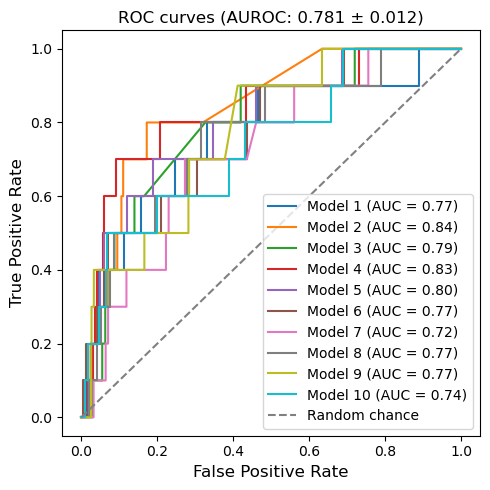

In [78]:
plot_roc_curves_from_tsvs(tsv_folder=output_direc,
                         plt_direc=output_direc+'all_AUROC.pdf')

In [64]:
'*.tsv'[-4:]

'.tsv'

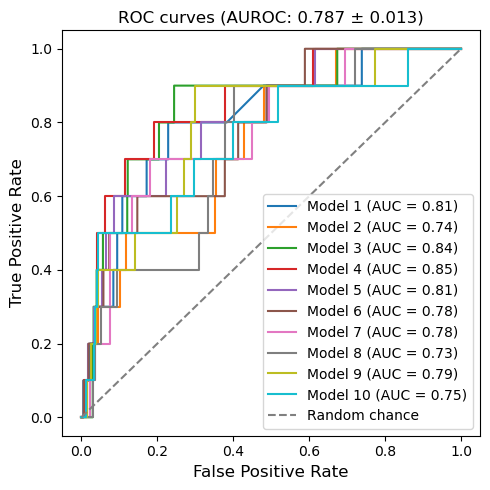

In [21]:
# PT10 version
# Overlay 10 ROC plots

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import glob
import os

def plot_roc_curves_from_tsvs(tsv_folder, prefix='nodup_NN_heldout_stringent2_',
                              file_pattern="*.tsv", 
                              start_i=1, end_i=11,
                              label_col="GI_stringent_Type2", prob_col="predict_proba",
                             plt_direc=None):
    """
    Reads TSV files from a folder and plots ROC curves for each file.
    
    Parameters:
    - tsv_folder: str, path to the folder containing TSV files.
    - file_pattern: str, glob pattern for selecting files (default is "*.tsv").
    - label_col: str, name of the true label column.
    - prob_col: str, name of the predicted probability column.
    """
    plt.figure(figsize=(5, 5))

    tsv_files = sorted(glob.glob(os.path.join(tsv_folder, file_pattern)))
    #print(tsv_files)
    
    final_files = []
    for i in range(start_i, end_i):
        filename = prefix+"{}".format(str(i))+file_pattern[-4:]
        #print(filename)
        for file in tsv_files:
            if file.endswith(filename):
                final_files.append(file)
    #print(final_files)
    for file in final_files:
        df = pd.read_csv(file, sep="\t", index_col=0)
        fpr, tpr, _ = roc_curve(df[label_col], df[prob_col])
        roc_auc = auc(fpr, tpr)
        label = os.path.basename(file)
        label = "Model " +label.split('_')[-1].split('.')[0]
        plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.2f})")

    # Plot chance line
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random chance')

    plt.xlabel("False Positive Rate", fontsize=12)
    plt.ylabel("True Positive Rate", fontsize=12)
    plt.title("ROC curves (AUROC: 0.787 ± 0.013)")
    plt.legend(loc="lower right")
    #plt.grid(True)
    plt.tight_layout()
    if plt_direc is not None:
        plt.savefig(plt_direc, dpi=300)
    plt.show()
    
output_direc = '/home/myersc/zhan6668/DepGI/data/output/heldout/GIV_24Q4/pt10/MTOR/CV2/'
plot_roc_curves_from_tsvs(tsv_folder=output_direc,
                         plt_direc=output_direc+'all_AUROC_pt10.pdf')

In [47]:
df_MTOR_output[df_MTOR_output['Query']=='MTOR'].sort_values('predict_proba', ascending=False)

,Gene,Query,qGI_score,FDR,GI_standard,GI_stringent,GI_standard_Type1,GI_standard_Type2,GI_standard_Type3,GI_stringent_Type1,GI_stringent_Type2,GI_stringent_Type3,prediction,predict_proba
1699545,RAB18,MTOR,0.338788,0.024584,positive,NaN,1,0,1,0,0,0,False,0.159175
239994,ARF4,MTOR,0.082075,0.990372,NaN,NaN,0,0,0,0,0,0,False,0.150517
1703353,TSSC1,MTOR,0.186412,0.588012,NaN,NaN,0,0,0,0,0,0,False,0.147690
1704311,ZEB1,MTOR,-0.303431,0.308683,NaN,NaN,0,0,0,0,0,0,False,0.147308
1703885,VPS52,MTOR,0.204873,0.442320,NaN,NaN,0,0,0,0,0,0,False,0.145740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1699112,PRELID1,MTOR,-0.061185,0.926246,NaN,NaN,0,0,0,0,0,0,False,0.003262
1700201,RPL12,MTOR,-0.007056,0.992497,NaN,NaN,0,0,0,0,0,0,False,0.002729
1275095,FXYD3,MTOR,-0.317701,0.105214,NaN,NaN,0,0,0,0,0,0,False,0.002709
75964,ADIRF,MTOR,0.089706,0.976413,NaN,NaN,0,0,0,0,0,0,False,0.002345


In [48]:
# What about CV1 model?

In [49]:
# Filter ABBA and self-interactions
models_direc = '/home/myersc/zhan6668/DepGI/data/output/cv1_24Q4/AE_ReLU/ReLU128_f/'

output_direc = '/home/myersc/zhan6668/DepGI/data/output/heldout/GIV_24Q4/CV1/'

In [50]:
perf_list = []
K = 100
start_i = 1
n = 10
for i in range(start_i, start_i+n):
    print(i)
    r = str(i)
    df_MTOR_output, stats_MTOR = NN_held_out_test(model_direc=models_direc+'CV1_811_GIV_NN_LR1e2_50e_p5_d01_{}.pth'.format(r),
                        df_SL=df_MTOR_heldout, label_col='GI_stringent_Type2',
                        plt_direc=output_direc+'nodup_NN_heldout_ROC_PR_stringent2_{}.pdf'.format(r),
                        output_table_direc=output_direc+'nodup_NN_heldout_stringent2_{}.tsv'.format(r),
                        scaler_direc=models_direc+'CV1_811_seed{}.joblib'.format(r), topk=K)
    perf_list.append(stats_MTOR)
df_perf = pd.DataFrame(perf_list, columns=['AUROC', 'AUPR', 'AP', "Recall@{}".format(K), "Precision@{}".format(K)])
df_perf.to_csv(output_direc+'CV1_performance_stats_{}folds.tsv'.format(n), sep='\t', index=False)
print(df_perf.mean(axis=0))
print(df_perf.std(axis=0))

1
Using cuda device
/home/myersc/zhan6668/DepGI/data/output/cv1_24Q4/AE_ReLU/ReLU128_f/CV1_811_GIV_NN_LR1e2_50e_p5_d01_1.pth
Entire model loaded successfully.
GI_stringent_Type2
(17132, 256)
Accuracy on test set: 99.94%
ROC AUC: 0.7580
PRC AUC: 0.0022
Average Precision: 0.0026
Recall@100: 0.0000
Precision@100: 0.0000
2
Using cuda device
/home/myersc/zhan6668/DepGI/data/output/cv1_24Q4/AE_ReLU/ReLU128_f/CV1_811_GIV_NN_LR1e2_50e_p5_d01_2.pth
Entire model loaded successfully.
GI_stringent_Type2
(17132, 256)
Accuracy on test set: 99.94%
ROC AUC: 0.8014
PRC AUC: 0.0022
Average Precision: 0.0027
Recall@100: 0.0000
Precision@100: 0.0000
3
Using cuda device
/home/myersc/zhan6668/DepGI/data/output/cv1_24Q4/AE_ReLU/ReLU128_f/CV1_811_GIV_NN_LR1e2_50e_p5_d01_3.pth
Entire model loaded successfully.
GI_stringent_Type2
(17132, 256)
Accuracy on test set: 99.94%
ROC AUC: 0.8289
PRC AUC: 0.0042
Average Precision: 0.0056
Recall@100: 0.1000
Precision@100: 0.0100
4
Using cuda device
/home/myersc/zhan6668/D

In [51]:
df_MTOR_output[df_MTOR_output['Query']=='MTOR'].sort_values('predict_proba', ascending=False)

,Gene,Query,qGI_score,FDR,GI_standard,GI_stringent,GI_standard_Type1,GI_standard_Type2,GI_standard_Type3,GI_stringent_Type1,GI_stringent_Type2,GI_stringent_Type3,prediction,predict_proba
1703296,TSC2,MTOR,0.533050,0.106739,NaN,NaN,0,0,0,0,0,0,False,0.144833
321301,ATG9A,MTOR,0.432536,0.262320,NaN,NaN,0,0,0,0,0,0,False,0.125484
1698155,PAXIP1,MTOR,0.442479,0.582160,NaN,NaN,0,0,0,0,0,0,False,0.124588
1698055,PAGR1,MTOR,0.086339,0.961816,NaN,NaN,0,0,0,0,0,0,False,0.119615
1696738,MYH9,MTOR,0.352138,0.160060,NaN,NaN,0,0,0,0,0,0,False,0.117016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1275095,FXYD3,MTOR,-0.317701,0.105214,NaN,NaN,0,0,0,0,0,0,False,0.005695
75964,ADIRF,MTOR,0.089706,0.976413,NaN,NaN,0,0,0,0,0,0,False,0.005599
1701705,SPINT2,MTOR,0.069607,0.910817,NaN,NaN,0,0,0,0,0,0,False,0.005398
1700201,RPL12,MTOR,-0.007056,0.992497,NaN,NaN,0,0,0,0,0,0,False,0.004600


In [28]:
cv1_models_direc = '/home/myersc/zhan6668/DepGI/data/output/cv1_24Q4/AE_ReLU/ReLU128_f/'
cv2_models_direc = '/home/myersc/zhan6668/DepGI/data/output/cv2_24Q4/AE_ReLU/ReLU128_f_a075_g15_10folds/'

In [29]:
cdg_overlap_genes = ['MYH9', 'TOP1', 'USP9X', 'WWTR1'] # MTOR

In [69]:
K = 100
start_i = 1
n = 10
for g in cdg_overlap_genes:
    print(g)
    cv1_output_direc = '/home/myersc/zhan6668/DepGI/data/output/heldout/GIV_24Q4/{}/CV1/'.format(g)
    cv2_output_direc = '/home/myersc/zhan6668/DepGI/data/output/heldout/GIV_24Q4/{}/CV2/'.format(g)
    
    # Create a directory if it does not exist
    create_directory(cv1_output_direc)
    create_directory(cv2_output_direc)
    
    df_g_heldout = df_SL_heldout[df_SL_heldout['Query']==g]
    
    print('CV1:')
    perf_list = []
    for i in range(start_i, start_i+n):
        print(i)
        r = str(i)
        
        df_output, stats = NN_held_out_test(model_direc=cv1_models_direc+'CV1_811_GIV_NN_LR1e2_50e_p5_d01_{}.pth'.format(r),
                            df_SL=df_g_heldout, label_col='GI_stringent_Type2',
                            plt_direc=cv1_output_direc+'nodup_NN_heldout_ROC_PR_stringent2_{}.pdf'.format(r),
                            output_table_direc=cv1_output_direc+'nodup_NN_heldout_stringent2_{}.tsv'.format(r),
                            scaler_direc=cv1_models_direc+'CV1_811_seed{}.joblib'.format(r), topk=K)
        perf_list.append(stats)
    df_perf = pd.DataFrame(perf_list, columns=['AUROC', 'AUPR', 'AP', "Recall@{}".format(K), "Precision@{}".format(K)])
    df_perf.to_csv(cv1_output_direc+'CV1_performance_stats_{}folds.tsv'.format(n), sep='\t', index=False)
    print(df_perf.mean(axis=0))
    print(df_perf.std(axis=0))
    
    print('\n\n CV2:')
    perf_list = []
    for i in range(start_i, start_i+n):
        print(i)
        r = str(i)
        df_output, stats = NN_held_out_test(model_direc=cv2_models_direc+'CV2_811_GIV_NN_LR1e2_50e_p5_d01_{}.pth'.format(r),
                            df_SL=df_g_heldout, label_col='GI_stringent_Type2',
                            plt_direc=cv2_output_direc+'nodup_NN_heldout_ROC_PR_stringent2_{}.pdf'.format(r),
                            output_table_direc=cv2_output_direc+'nodup_NN_heldout_stringent2_{}.tsv'.format(r),
                            scaler_direc=cv2_models_direc+'CV2_811_seed{}.joblib'.format(r), topk=K)
        perf_list.append(stats)
    df_perf = pd.DataFrame(perf_list, columns=['AUROC', 'AUPR', 'AP', "Recall@{}".format(K), "Precision@{}".format(K)])
    df_perf.to_csv(cv2_output_direc+'CV2_performance_stats_{}folds.tsv'.format(n), sep='\t', index=False)
    print(df_perf.mean(axis=0))
    print(df_perf.std(axis=0))
    
    print(g, '\n\n\n\n\n')


MYH9
Directory '/home/myersc/zhan6668/DepGI/data/output/heldout/GIV_24Q4/MYH9/CV1/' is ready.
Directory '/home/myersc/zhan6668/DepGI/data/output/heldout/GIV_24Q4/MYH9/CV2/' is ready.
CV1:
1
Using cuda device
/home/myersc/zhan6668/DepGI/data/output/cv1_24Q4/AE_ReLU/ReLU128_f/CV1_811_GIV_NN_LR1e2_50e_p5_d01_1.pth
Entire model loaded successfully.
GI_stringent_Type2
(17132, 256)
Accuracy on test set: 99.94%
ROC AUC: 0.7369
PRC AUC: 0.0013
Average Precision: 0.0015
Recall@100: 0.0000
Precision@100: 0.0000
2
Using cuda device
/home/myersc/zhan6668/DepGI/data/output/cv1_24Q4/AE_ReLU/ReLU128_f/CV1_811_GIV_NN_LR1e2_50e_p5_d01_2.pth
Entire model loaded successfully.
GI_stringent_Type2
(17132, 256)
Accuracy on test set: 99.94%
ROC AUC: 0.6442
PRC AUC: 0.0009
Average Precision: 0.0011
Recall@100: 0.0000
Precision@100: 0.0000
3
Using cuda device
/home/myersc/zhan6668/DepGI/data/output/cv1_24Q4/AE_ReLU/ReLU128_f/CV1_811_GIV_NN_LR1e2_50e_p5_d01_3.pth
Entire model loaded successfully.
GI_stringent_Ty

In [15]:
# Study USP9X as it has the best results
df_USP9X = df_SL_heldout[df_SL_heldout['Query']=='USP9X'][non_feature_cols]

In [16]:
df_USP9X

,Gene,Query,qGI_score,FDR,GI_standard,GI_stringent,GI_standard_Type1,GI_standard_Type2,GI_standard_Type3,GI_stringent_Type1,GI_stringent_Type2,GI_stringent_Type3
116,A1BG,USP9X,-0.108204,0.981237,NaN,NaN,0,0,0,0,0,0
239,A1CF,USP9X,-0.046857,0.926819,NaN,NaN,0,0,0,0,0,0
362,A2M,USP9X,0.298227,0.338419,NaN,NaN,0,0,0,0,0,0
485,A2ML1,USP9X,0.004029,0.767808,NaN,NaN,0,0,0,0,0,0
608,A3GALT2,USP9X,0.042716,0.956723,NaN,NaN,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2175742,ZYG11A,USP9X,0.181024,0.709944,NaN,NaN,0,0,0,0,0,0
2175743,ZYG11B,USP9X,0.142940,0.888317,NaN,NaN,0,0,0,0,0,0
2175744,ZYX,USP9X,0.105898,0.977028,NaN,NaN,0,0,0,0,0,0
2175745,ZZEF1,USP9X,0.167394,0.948545,NaN,NaN,0,0,0,0,0,0


In [18]:
df_USP9X_SL = df_USP9X[df_USP9X['GI_stringent_Type2']==1]

In [19]:
df_USP9X_SL.shape

(28, 12)

In [20]:
df_USP9X_SL

,Gene,Query,qGI_score,FDR,GI_standard,GI_stringent,GI_standard_Type1,GI_standard_Type2,GI_standard_Type3,GI_stringent_Type1,GI_stringent_Type2,GI_stringent_Type3
240276,ARF6,USP9X,-0.776737,5.403419e-12,negative,negative,1,1,0,1,1,0
271929,ARNT,USP9X,-0.616458,8.835846e-03,negative,negative,1,1,0,1,1,0
451579,BTAF1,USP9X,-0.601120,2.616835e-04,negative,negative,1,1,0,1,1,0
467736,C14orf142,USP9X,-0.746058,2.194501e-03,negative,negative,1,1,0,1,1,0
473086,C16orf72,USP9X,-0.790561,6.221917e-05,negative,negative,1,1,0,1,1,0
904075,CSTF2,USP9X,-0.965877,1.232290e-06,negative,negative,1,1,0,1,1,0
934460,CYP2S1,USP9X,-0.647662,2.054742e-04,negative,negative,1,1,0,1,1,0
1046600,DOK2,USP9X,-0.617601,3.905804e-04,negative,negative,1,1,0,1,1,0
1114640,EAF1,USP9X,-0.682933,1.625057e-05,negative,negative,1,1,0,1,1,0
1268611,FOXRED1,USP9X,-0.814851,4.692793e-04,negative,negative,1,1,0,1,1,0


In [22]:
df_USP9X_SL['Gene'].values

array(['ARF6', 'ARNT', 'BTAF1', 'C14orf142', 'C16orf72', 'CSTF2',
       'CYP2S1', 'DOK2', 'EAF1', 'FOXRED1', 'GCHFR', 'GCSH', 'HEATR2',
       'MCM9', 'MEAF6', 'METTL23', 'NDUFAF6', 'NDUFB8', 'NDUFS3', 'NXT1',
       'PIH1D1', 'PRRC2A', 'RBM14', 'STAG2', 'STRAP', 'TRIM37', 'TXNDC17',
       'UIMC1'], dtype=object)

In [23]:
for g in df_USP9X_SL['Gene'].values:
    print(g)

ARF6
ARNT
BTAF1
C14orf142
C16orf72
CSTF2
CYP2S1
DOK2
EAF1
FOXRED1
GCHFR
GCSH
HEATR2
MCM9
MEAF6
METTL23
NDUFAF6
NDUFB8
NDUFS3
NXT1
PIH1D1
PRRC2A
RBM14
STAG2
STRAP
TRIM37
TXNDC17
UIMC1


In [31]:
cv1_models_direc = '/home/myersc/zhan6668/DepGI/data/output/cv1_24Q4/AE_ReLU/ReLU128_f/'
cv2_models_direc = '/home/myersc/zhan6668/DepGI/data/output/cv2_24Q4/AE_ReLU/ReLU128_f_a075_g15_10folds/'

In [32]:
cdg_overlap_genes = ['MTOR', 'MYH9', 'TOP1', 'USP9X', 'WWTR1']

In [33]:
# Check every gene's performance if predicted on standard negative GIs
K = 100
start_i = 1
n = 10
for g in cdg_overlap_genes:
    print(g)
    cv1_output_direc = '/home/myersc/zhan6668/DepGI/data/output/heldout/GIV_24Q4/std/{}/CV1/'.format(g)
    cv2_output_direc = '/home/myersc/zhan6668/DepGI/data/output/heldout/GIV_24Q4/std/{}/CV2/'.format(g)
    
    # Create a directory if it does not exist
    create_directory(cv1_output_direc)
    create_directory(cv2_output_direc)
    
    df_g_heldout = df_SL_heldout[df_SL_heldout['Query']==g]
    
    print('CV1:')
    perf_list = []
    for i in range(start_i, start_i+n):
        print(i)
        r = str(i)
        
        df_output, stats = NN_held_out_test(model_direc=cv1_models_direc+'CV1_811_GIV_NN_LR1e2_50e_p5_d01_{}.pth'.format(r),
                            df_SL=df_g_heldout, label_col='GI_standard_Type2',
                            plt_direc=cv1_output_direc+'nodup_NN_heldout_ROC_PR_stringent2_{}.pdf'.format(r),
                            output_table_direc=cv1_output_direc+'nodup_NN_heldout_stringent2_{}.tsv'.format(r),
                            scaler_direc=cv1_models_direc+'CV1_811_seed{}.joblib'.format(r), topk=K)
        perf_list.append(stats)
    df_perf = pd.DataFrame(perf_list, columns=['AUROC', 'AUPR', 'AP', "Recall@{}".format(K), "Precision@{}".format(K)])
    df_perf.to_csv(cv1_output_direc+'CV1_performance_stats_{}folds.tsv'.format(n), sep='\t', index=False)
    print(df_perf.mean(axis=0))
    print(df_perf.std(axis=0))
    
    print('\n\n CV2:')
    perf_list = []
    for i in range(start_i, start_i+n):
        print(i)
        r = str(i)
        df_output, stats = NN_held_out_test(model_direc=cv2_models_direc+'CV2_811_GIV_NN_LR1e2_50e_p5_d01_{}.pth'.format(r),
                            df_SL=df_g_heldout, label_col='GI_standard_Type2',
                            plt_direc=cv2_output_direc+'nodup_NN_heldout_ROC_PR_stringent2_{}.pdf'.format(r),
                            output_table_direc=cv2_output_direc+'nodup_NN_heldout_stringent2_{}.tsv'.format(r),
                            scaler_direc=cv2_models_direc+'CV2_811_seed{}.joblib'.format(r), topk=K)
        perf_list.append(stats)
    df_perf = pd.DataFrame(perf_list, columns=['AUROC', 'AUPR', 'AP', "Recall@{}".format(K), "Precision@{}".format(K)])
    df_perf.to_csv(cv2_output_direc+'CV2_performance_stats_{}folds.tsv'.format(n), sep='\t', index=False)
    print(df_perf.mean(axis=0))
    print(df_perf.std(axis=0))
    
    print(g, '\n\n\n\n\n')


MTOR
Directory '/home/myersc/zhan6668/DepGI/data/output/heldout/GIV_24Q4/std/MTOR/CV1/' is ready.
Directory '/home/myersc/zhan6668/DepGI/data/output/heldout/GIV_24Q4/std/MTOR/CV2/' is ready.
CV1:
1
Using cuda device
/home/myersc/zhan6668/DepGI/data/output/cv1_24Q4/AE_ReLU/ReLU128_f/CV1_811_GIV_NN_LR1e2_50e_p5_d01_1.pth
Entire model loaded successfully.
GI_standard_Type2
(17132, 256)
Accuracy on test set: 99.30%
ROC AUC: 0.6041
PRC AUC: 0.0128
Average Precision: 0.0135
Recall@100: 0.0333
Precision@100: 0.0400
2
Using cuda device
/home/myersc/zhan6668/DepGI/data/output/cv1_24Q4/AE_ReLU/ReLU128_f/CV1_811_GIV_NN_LR1e2_50e_p5_d01_2.pth
Entire model loaded successfully.
GI_standard_Type2
(17132, 256)
Accuracy on test set: 99.30%
ROC AUC: 0.6084
PRC AUC: 0.0127
Average Precision: 0.0132
Recall@100: 0.0250
Precision@100: 0.0300
3
Using cuda device
/home/myersc/zhan6668/DepGI/data/output/cv1_24Q4/AE_ReLU/ReLU128_f/CV1_811_GIV_NN_LR1e2_50e_p5_d01_3.pth
Entire model loaded successfully.
GI_standa

In [ ]:
# PT10

In [15]:
cv1_models_direc = '/home/myersc/zhan6668/DepGI/data/output/cv1_24Q4/AE_ReLU/ReLU128_f_pt10/'
cv2_models_direc = '/home/myersc/zhan6668/DepGI/data/output/cv2_24Q4/AE_ReLU/ReLU128_f_a075_g15_10folds_pt10/'

In [16]:
cdg_overlap_genes = ['MTOR', 'MYH9', 'TOP1', 'USP9X', 'WWTR1']

In [17]:
# Check every gene's performance if predicted on stringent negative GIs, with pt10 model
K = 100
start_i = 1
n = 10
for g in cdg_overlap_genes:
    print(g)
    cv1_output_direc = '/home/myersc/zhan6668/DepGI/data/output/heldout/GIV_24Q4/pt10/{}/CV1/'.format(g)
    cv2_output_direc = '/home/myersc/zhan6668/DepGI/data/output/heldout/GIV_24Q4/pt10/{}/CV2/'.format(g)
    
    # Create a directory if it does not exist
    create_directory(cv1_output_direc)
    create_directory(cv2_output_direc)
    
    df_g_heldout = df_SL_heldout[df_SL_heldout['Query']==g]
    
    print('CV1:')
    perf_list = []
    for i in range(start_i, start_i+n):
        print(i)
        r = str(i)
        
        df_output, stats = NN_held_out_test(model_direc=cv1_models_direc+'CV1_811_GIV_NN_LR1e2_50e_p10_d01_{}.pth'.format(r),
                            df_SL=df_g_heldout, label_col='GI_stringent_Type2',
                            plt_direc=cv1_output_direc+'nodup_NN_heldout_ROC_PR_stringent2_{}.pdf'.format(r),
                            output_table_direc=cv1_output_direc+'nodup_NN_heldout_stringent2_{}.tsv'.format(r),
                            scaler_direc=cv1_models_direc+'CV1_811_seed{}.joblib'.format(r), topk=K)
        perf_list.append(stats)
    df_perf = pd.DataFrame(perf_list, columns=['AUROC', 'AUPR', 'AP', "Recall@{}".format(K), "Precision@{}".format(K)])
    df_perf.to_csv(cv1_output_direc+'CV1_performance_stats_{}folds.tsv'.format(n), sep='\t', index=False)
    print(df_perf.mean(axis=0))
    print(df_perf.std(axis=0))
    
    print('\n\n CV2:')
    perf_list = []
    for i in range(start_i, start_i+n):
        print(i)
        r = str(i)
        df_output, stats = NN_held_out_test(model_direc=cv2_models_direc+'CV2_811_GIV_NN_LR1e2_50e_p10_d01_{}.pth'.format(r),
                            df_SL=df_g_heldout, label_col='GI_stringent_Type2',
                            plt_direc=cv2_output_direc+'nodup_NN_heldout_ROC_PR_stringent2_{}.pdf'.format(r),
                            output_table_direc=cv2_output_direc+'nodup_NN_heldout_stringent2_{}.tsv'.format(r),
                            scaler_direc=cv2_models_direc+'CV2_811_seed{}.joblib'.format(r), topk=K)
        perf_list.append(stats)
    df_perf = pd.DataFrame(perf_list, columns=['AUROC', 'AUPR', 'AP', "Recall@{}".format(K), "Precision@{}".format(K)])
    df_perf.to_csv(cv2_output_direc+'CV2_performance_stats_{}folds.tsv'.format(n), sep='\t', index=False)
    print(df_perf.mean(axis=0))
    print(df_perf.std(axis=0))
    
    print(g, '\n\n\n\n\n')


MTOR
Directory '/home/myersc/zhan6668/DepGI/data/output/heldout/GIV_24Q4/pt10/MTOR/CV1/' is ready.
Directory '/home/myersc/zhan6668/DepGI/data/output/heldout/GIV_24Q4/pt10/MTOR/CV2/' is ready.
CV1:
1
Using cuda device
/home/myersc/zhan6668/DepGI/data/output/cv1_24Q4/AE_ReLU/ReLU128_f_pt10/CV1_811_GIV_NN_LR1e2_50e_p10_d01_1.pth
Entire model loaded successfully.
GI_stringent_Type2
(17132, 256)
Accuracy on test set: 99.94%
ROC AUC: 0.7952
PRC AUC: 0.0023
Average Precision: 0.0027
Recall@100: 0.0000
Precision@100: 0.0000
2
Using cuda device
/home/myersc/zhan6668/DepGI/data/output/cv1_24Q4/AE_ReLU/ReLU128_f_pt10/CV1_811_GIV_NN_LR1e2_50e_p10_d01_2.pth
Entire model loaded successfully.
GI_stringent_Type2
(17132, 256)
Accuracy on test set: 99.94%
ROC AUC: 0.8034
PRC AUC: 0.0020
Average Precision: 0.0024
Recall@100: 0.0000
Precision@100: 0.0000
3
Using cuda device
/home/myersc/zhan6668/DepGI/data/output/cv1_24Q4/AE_ReLU/ReLU128_f_pt10/CV1_811_GIV_NN_LR1e2_50e_p10_d01_3.pth
Entire model loaded s